In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


In [2]:
# Carrega apenas as colunas essenciais para economizar memória
colunas = [
    'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
    'DEPARTURE_DELAY', 'DISTANCE', 'ELAPSED_TIME',
    'ARRIVAL_DELAY', 'CANCELLED', 'DIVERTED',
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
    'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

df = pd.read_csv('flights.csv', usecols=colunas, nrows=1_000_000)

print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
print(f"Memória usada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Linhas: 1,000,000
Colunas: 19
Memória usada: 269.9 MB


In [3]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,ELAPSED_TIME,DISTANCE,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,ANC,SEA,5,-11.0,194.0,1448,-22.0,0,0,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,LAX,PBI,10,-8.0,279.0,2330,-9.0,0,0,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,SFO,CLT,20,-2.0,293.0,2296,5.0,0,0,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,LAX,MIA,20,-5.0,281.0,2342,-9.0,0,0,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,SEA,ANC,25,-1.0,215.0,1448,-21.0,0,0,NaN,NaN,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 19 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   YEAR                 1000000 non-null  int64  
 1   MONTH                1000000 non-null  int64  
 2   DAY                  1000000 non-null  int64  
 3   DAY_OF_WEEK          1000000 non-null  int64  
 4   AIRLINE              1000000 non-null  str    
 5   ORIGIN_AIRPORT       1000000 non-null  str    
 6   DESTINATION_AIRPORT  1000000 non-null  str    
 7   SCHEDULED_DEPARTURE  1000000 non-null  int64  
 8   DEPARTURE_DELAY      960842 non-null   float64
 9   ELAPSED_TIME         957394 non-null   float64
 10  DISTANCE             1000000 non-null  int64  
 11  ARRIVAL_DELAY        957394 non-null   float64
 12  DIVERTED             1000000 non-null  int64  
 13  CANCELLED            1000000 non-null  int64  
 14  AIR_SYSTEM_DELAY     221041 non-null   float64
 15  SECURITY_D

In [5]:
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,ELAPSED_TIME,DISTANCE,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,1000000.0,1000000.000000,1000000.000000,1000000.000000,1000000.000000,960842.000000,957394.000000,1000000.000000,957394.000000,1000000.000000,1000000.000000,221041.000000,221041.000000,221041.000000,221041.000000,221041.000000
mean,2015.0,1.630873,14.087290,3.942253,1322.605368,11.525092,136.954292,802.344535,7.904573,0.002474,0.040132,13.879651,0.057921,18.040721,22.955108,3.631589
std,0.0,0.659208,8.846599,1.957458,470.183312,39.451588,73.952304,593.929906,42.383991,0.049678,0.196269,25.747212,1.803159,46.037156,41.895492,23.792253
min,2015.0,1.000000,1.000000,1.000000,5.000000,-61.000000,15.000000,31.000000,-82.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.0,1.000000,6.000000,2.000000,920.000000,-5.000000,82.000000,366.000000,-12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2015.0,2.000000,14.000000,4.000000,1320.000000,-1.000000,119.000000,641.000000,-3.000000,0.000000,0.000000,4.000000,0.000000,2.000000,4.000000,0.000000
75%,2015.0,2.000000,22.000000,6.000000,1720.000000,11.000000,169.000000,1046.000000,12.000000,0.000000,0.000000,19.000000,0.000000,18.000000,29.000000,0.000000
max,2015.0,3.000000,31.000000,7.000000,2359.000000,1988.000000,766.000000,4983.000000,1971.000000,1.000000,1.000000,830.000000,241.000000,1971.000000,1313.000000,1152.000000


In [6]:
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'percentual': (df.isnull().sum() / len(df) * 100).round(2)
})

nulos = nulos[nulos['nulos'] > 0].sort_values('percentual', ascending=False)
print(nulos)

                      nulos  percentual
AIR_SYSTEM_DELAY     778959       77.90
LATE_AIRCRAFT_DELAY  778959       77.90
AIRLINE_DELAY        778959       77.90
SECURITY_DELAY       778959       77.90
WEATHER_DELAY        778959       77.90
ELAPSED_TIME          42606        4.26
ARRIVAL_DELAY         42606        4.26
DEPARTURE_DELAY       39158        3.92


In [7]:
# Remover voos cancelados
df = df[df['CANCELLED'] == 0].copy()

# Preencher causas de atraso com 0
colunas_atraso = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 
                  'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
df[colunas_atraso] = df[colunas_atraso].fillna(0)

# Remover nulos restantes
df = df.dropna(subset=['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'ELAPSED_TIME'])

print(f"Linhas após limpeza: {df.shape[0]:,}")
print(f"\nNulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Linhas após limpeza: 957,394

Nulos restantes:
Series([], dtype: int64)


In [8]:
# Criar coluna binária: 1 = atrasou (>= 15 min), 0 = não atrasou
df['ATRASADO'] = (df['ARRIVAL_DELAY'] >= 15).astype(int)

# Verificar distribuição
total = len(df)
atrasados = df['ATRASADO'].sum()
nao_atrasados = total - atrasados

print(f"Total de voos: {total:,}")
print(f"Atrasados (>= 15 min): {atrasados:,} ({atrasados/total*100:.1f}%)")
print(f"Não atrasados: {nao_atrasados:,} ({nao_atrasados/total*100:.1f}%)")

Total de voos: 957,394
Atrasados (>= 15 min): 221,041 (23.1%)
Não atrasados: 736,353 (76.9%)


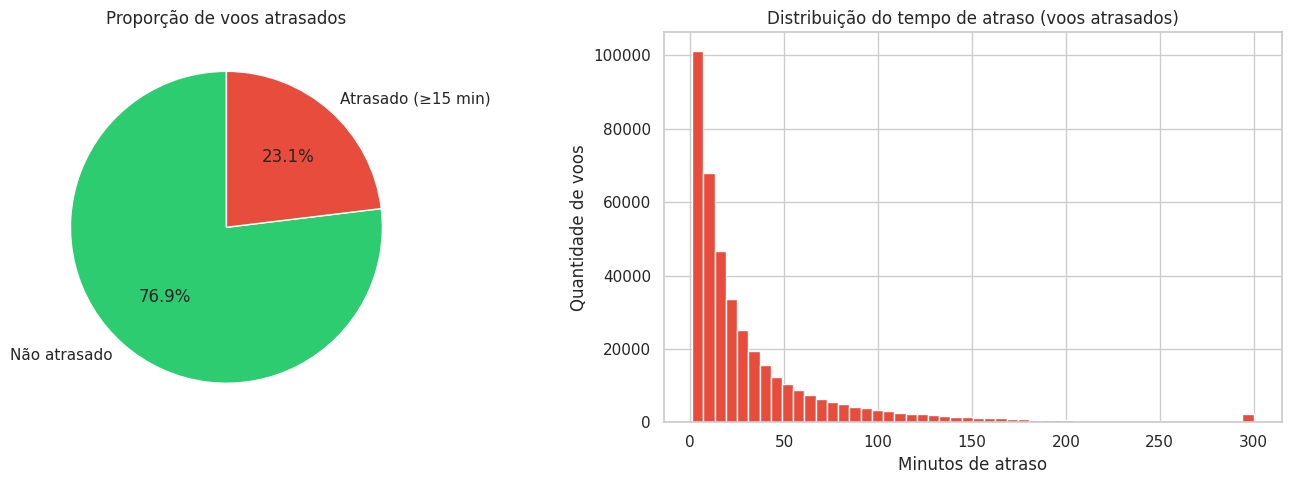

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: pizza
axes[0].pie(
    [nao_atrasados, atrasados],
    labels=['Não atrasado', 'Atrasado (≥15 min)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[0].set_title('Proporção de voos atrasados')

# Gráfico 2: distribuição do tempo de atraso
atraso_positivo = df[df['ARRIVAL_DELAY'] > 0]['ARRIVAL_DELAY'].clip(upper=300)
axes[1].hist(atraso_positivo, bins=50, color='#e74c3c', edgecolor='white')
axes[1].set_title('Distribuição do tempo de atraso (voos atrasados)')
axes[1].set_xlabel('Minutos de atraso')
axes[1].set_ylabel('Quantidade de voos')

plt.tight_layout()
plt.show()

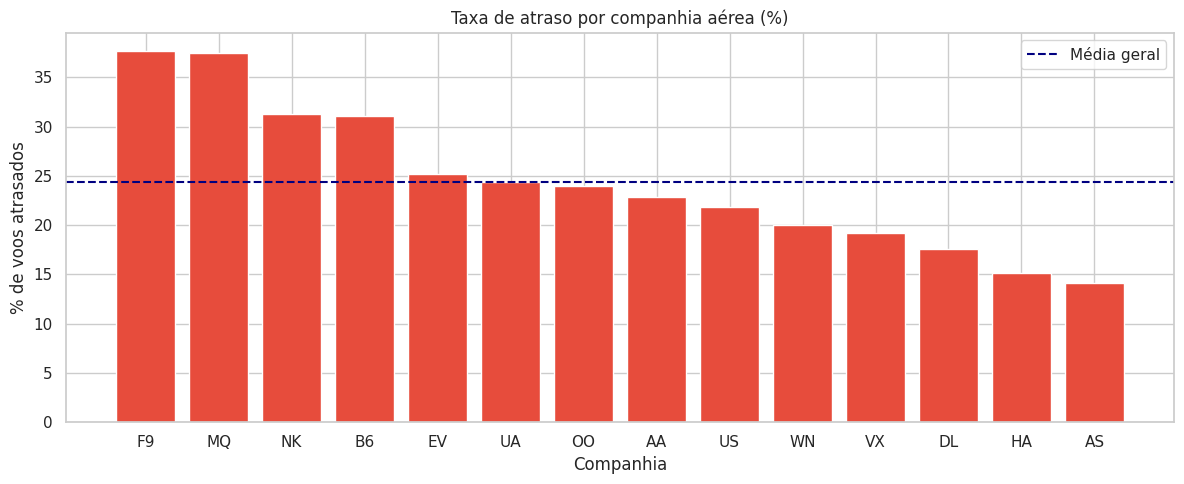

AIRLINE
F9    37.6
MQ    37.5
NK    31.3
B6    31.0
EV    25.1
UA    24.4
OO    24.0
AA    22.9
US    21.8
WN    20.0
VX    19.2
DL    17.6
HA    15.1
AS    14.2
Name: ATRASADO, dtype: float64


In [10]:
atraso_airline = df.groupby('AIRLINE')['ATRASADO'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 5))
bars = plt.bar(atraso_airline.index, atraso_airline.values, color='#e74c3c', edgecolor='white')
plt.title('Taxa de atraso por companhia aérea (%)')
plt.xlabel('Companhia')
plt.ylabel('% de voos atrasados')
plt.axhline(y=atraso_airline.mean(), color='navy', linestyle='--', label='Média geral')
plt.legend()
plt.tight_layout()
plt.show()

print(atraso_airline.round(1))

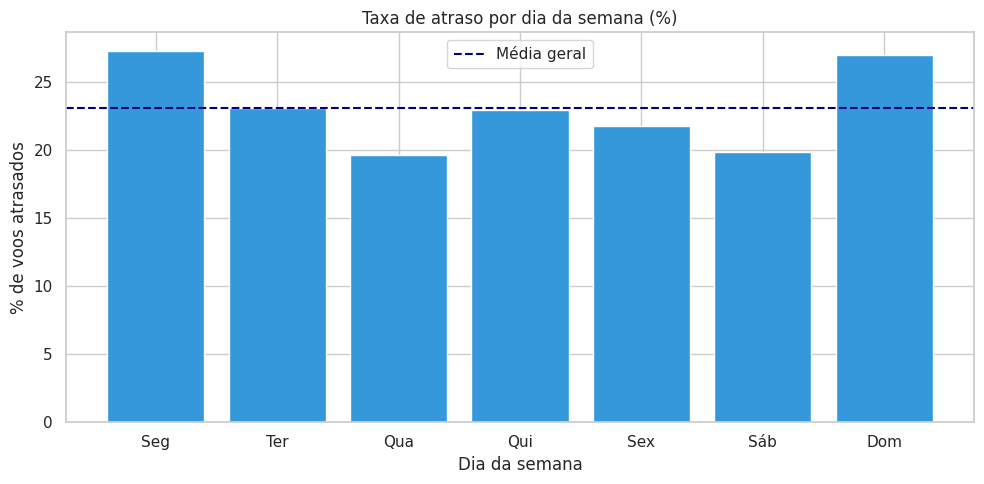

DAY_OF_WEEK
Seg    27.3
Ter    23.1
Qua    19.6
Qui    23.0
Sex    21.8
Sáb    19.9
Dom    27.0
Name: ATRASADO, dtype: float64


In [11]:
dias = {1: 'Seg', 2: 'Ter', 3: 'Qua', 4: 'Qui', 5: 'Sex', 6: 'Sáb', 7: 'Dom'}

atraso_dia = df.groupby('DAY_OF_WEEK')['ATRASADO'].mean() * 100
atraso_dia.index = atraso_dia.index.map(dias)

plt.figure(figsize=(10, 5))
bars = plt.bar(atraso_dia.index, atraso_dia.values, color='#3498db', edgecolor='white')
plt.title('Taxa de atraso por dia da semana (%)')
plt.xlabel('Dia da semana')
plt.ylabel('% de voos atrasados')
plt.axhline(y=atraso_dia.mean(), color='navy', linestyle='--', label='Média geral')
plt.legend()
plt.tight_layout()
plt.show()

print(atraso_dia.round(1))

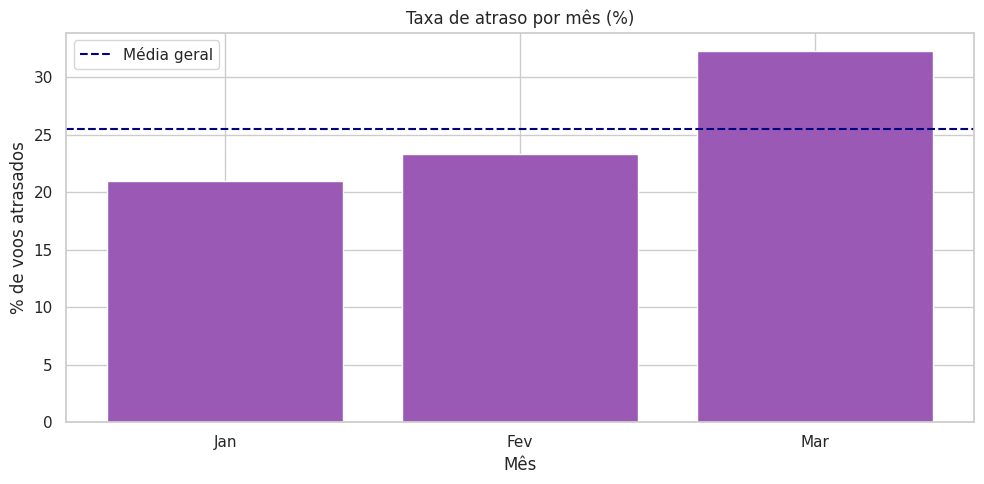

MONTH
Jan    21.0
Fev    23.3
Mar    32.3
Name: ATRASADO, dtype: float64


In [12]:
meses = {1: 'Jan', 2: 'Fev', 3: 'Mar'}

atraso_mes = df.groupby('MONTH')['ATRASADO'].mean() * 100
atraso_mes.index = atraso_mes.index.map(meses)

plt.figure(figsize=(10, 5))
plt.bar(atraso_mes.index, atraso_mes.values, color='#9b59b6', edgecolor='white')
plt.title('Taxa de atraso por mês (%)')
plt.xlabel('Mês')
plt.ylabel('% de voos atrasados')
plt.axhline(y=atraso_mes.mean(), color='navy', linestyle='--', label='Média geral')
plt.legend()
plt.tight_layout()
plt.show()

print(atraso_mes.round(1))

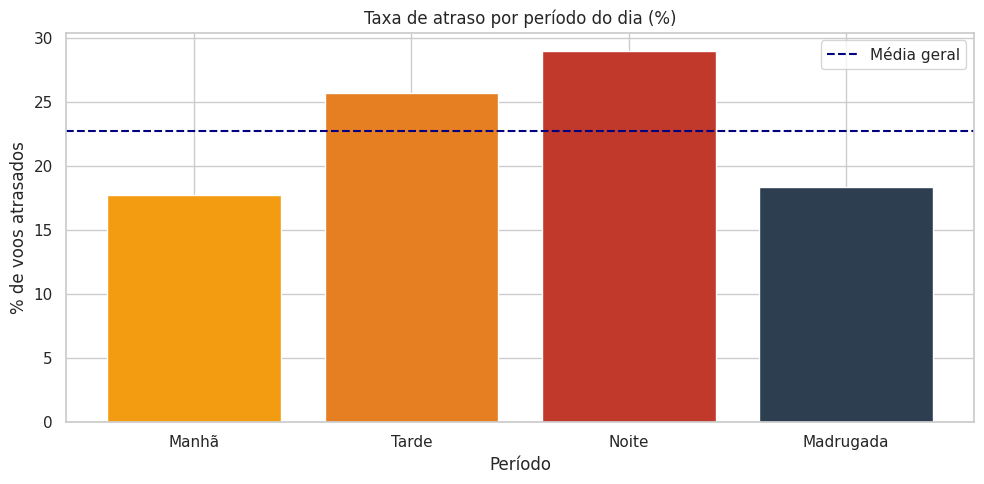

PERIODO
1-Manhã        17.8
2-Tarde        25.7
3-Noite        29.0
4-Madrugada    18.4
Name: ATRASADO, dtype: float64


In [13]:
# Criar faixas de horário a partir do SCHEDULED_DEPARTURE
def periodo_dia(hora):
    hora = int(str(int(hora)).zfill(4)[:2])
    if 5 <= hora < 12:
        return '1-Manhã'
    elif 12 <= hora < 18:
        return '2-Tarde'
    elif 18 <= hora < 24:
        return '3-Noite'
    else:
        return '4-Madrugada'

df['PERIODO'] = df['SCHEDULED_DEPARTURE'].apply(periodo_dia)

atraso_periodo = df.groupby('PERIODO')['ATRASADO'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(
    ['Manhã', 'Tarde', 'Noite', 'Madrugada'],
    atraso_periodo.values,
    color=['#f39c12', '#e67e22', '#c0392b', '#2c3e50'],
    edgecolor='white'
)
plt.title('Taxa de atraso por período do dia (%)')
plt.xlabel('Período')
plt.ylabel('% de voos atrasados')
plt.axhline(y=atraso_periodo.mean(), color='navy', linestyle='--', label='Média geral')
plt.legend()
plt.tight_layout()
plt.show()

print(atraso_periodo.round(1))

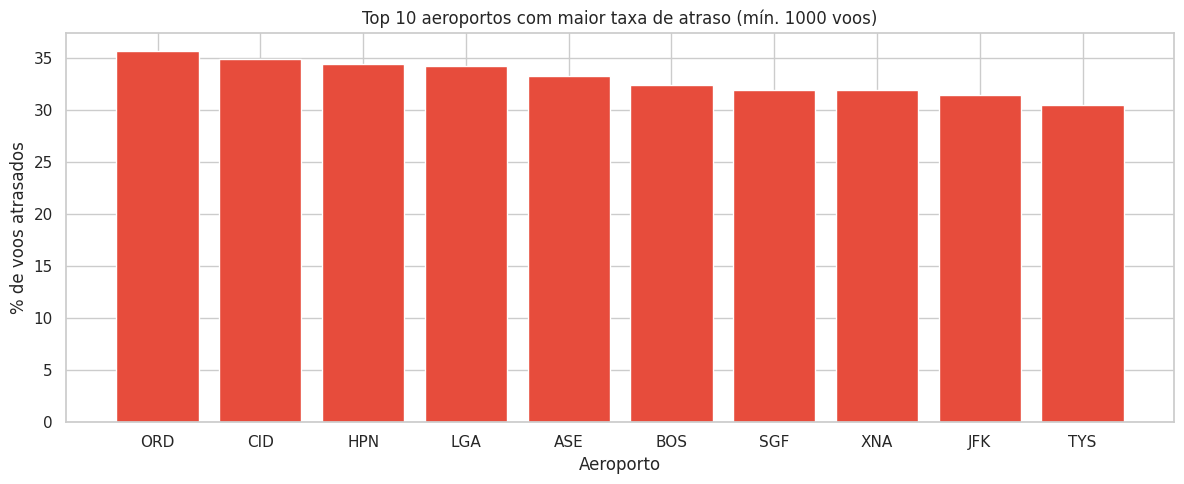

ORIGIN_AIRPORT
ORD    35.6
CID    34.8
HPN    34.4
LGA    34.2
ASE    33.3
BOS    32.4
SGF    31.9
XNA    31.9
JFK    31.4
TYS    30.5
Name: ATRASADO, dtype: float64


In [14]:
# Aeroportos com pelo menos 1000 voos para ter representatividade
voos_por_aeroporto = df.groupby('ORIGIN_AIRPORT').size()
aeroportos_validos = voos_por_aeroporto[voos_por_aeroporto >= 1000].index

atraso_aeroporto = df[df['ORIGIN_AIRPORT'].isin(aeroportos_validos)]\
    .groupby('ORIGIN_AIRPORT')['ATRASADO']\
    .mean() * 100

atraso_aeroporto = atraso_aeroporto.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(atraso_aeroporto.index, atraso_aeroporto.values, color='#e74c3c', edgecolor='white')
plt.title('Top 10 aeroportos com maior taxa de atraso (mín. 1000 voos)')
plt.xlabel('Aeroporto')
plt.ylabel('% de voos atrasados')
plt.tight_layout()
plt.show()

print(atraso_aeroporto.round(1))

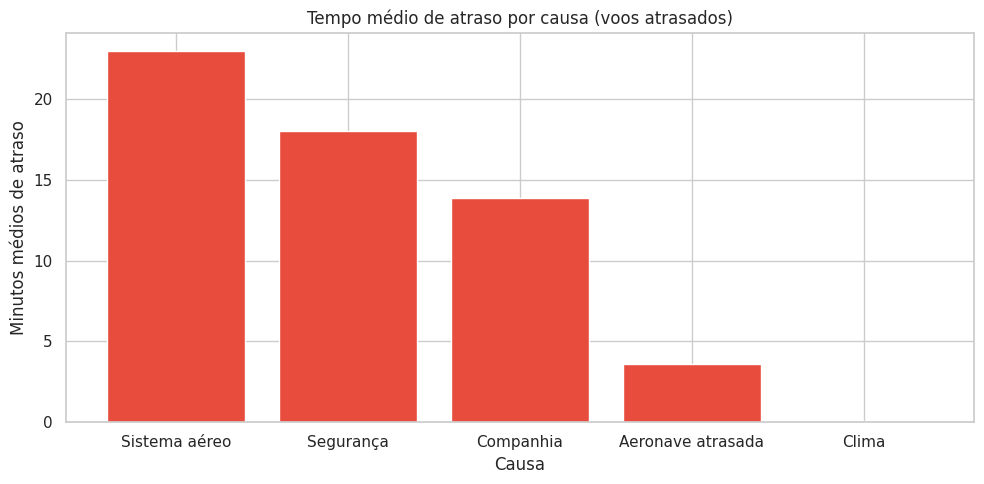

Sistema aéreo        23.0
Segurança            18.0
Companhia            13.9
Aeronave atrasada     3.6
Clima                 0.1
dtype: float64


In [15]:
causas = df[df['ATRASADO'] == 1][
    ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 
     'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
].mean().sort_values(ascending=False)

causas.index = ['Sistema aéreo', 'Segurança', 'Companhia', 'Aeronave atrasada', 'Clima']

plt.figure(figsize=(10, 5))
plt.bar(causas.index, causas.values, color='#e74c3c', edgecolor='white')
plt.title('Tempo médio de atraso por causa (voos atrasados)')
plt.xlabel('Causa')
plt.ylabel('Minutos médios de atraso')
plt.tight_layout()
plt.show()

print(causas.round(1))

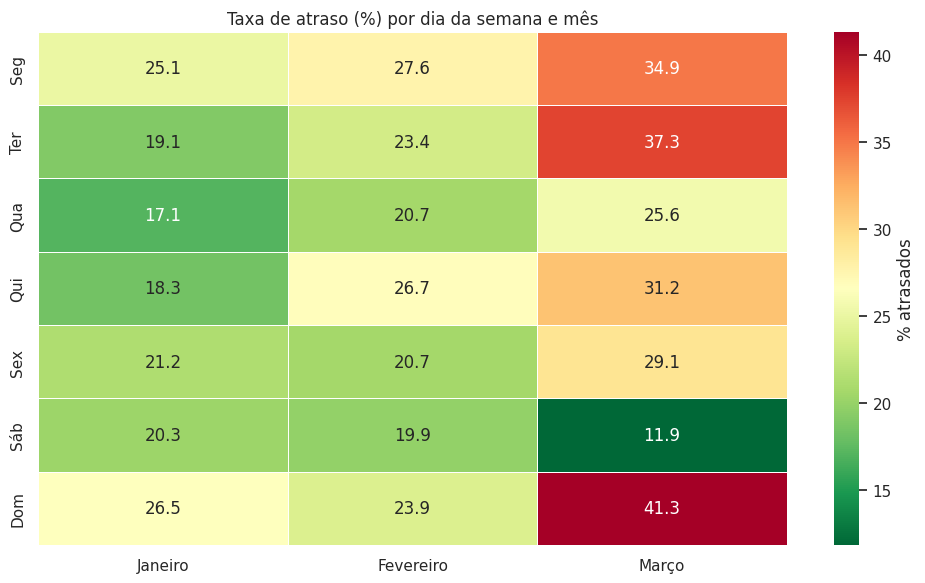

In [16]:
pivot = df.pivot_table(
    values='ATRASADO',
    index='DAY_OF_WEEK',
    columns='MONTH',
    aggfunc='mean'
) * 100

pivot.index = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
pivot.columns = ['Janeiro', 'Fevereiro', 'Março']

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': '% atrasados'}
)
plt.title('Taxa de atraso (%) por dia da semana e mês')
plt.tight_layout()
plt.show()

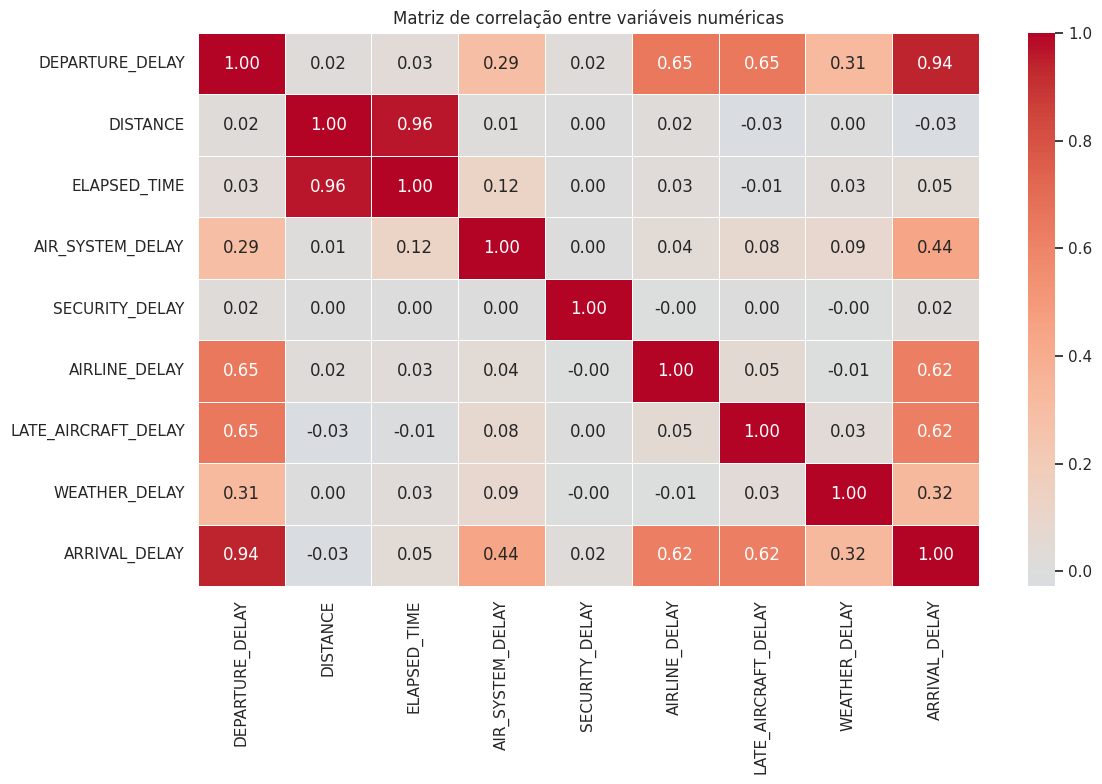

In [17]:
colunas_corr = [
    'DEPARTURE_DELAY', 'DISTANCE', 'ELAPSED_TIME',
    'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'ARRIVAL_DELAY'
]

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[colunas_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Matriz de correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

In [18]:
print("""
RESUMO DA EDA
=============
Total de voos analisados : 957.394
Taxa geral de atraso     : 23.1%

Piores companhias        : F9 (37.6%) e MQ (37.5%)
Melhores companhias      : AS (14.2%) e HA (15.1%)

Pior dia da semana       : Segunda-feira (27.3%)
Melhor dia               : Quarta-feira (19.6%)

Pior período do dia      : Noite (29.0%)
Melhor período           : Manhã (17.8%)

Pior mês                 : Março (32.3%)
Aeroporto mais crítico   : ORD - Chicago (35.6%)

Principal causa de atraso: Sistema aéreo (23 min médios)
Maior correlação c/ atraso: DEPARTURE_DELAY e causas operacionais
""")


RESUMO DA EDA
Total de voos analisados : 957.394
Taxa geral de atraso     : 23.1%

Piores companhias        : F9 (37.6%) e MQ (37.5%)
Melhores companhias      : AS (14.2%) e HA (15.1%)

Pior dia da semana       : Segunda-feira (27.3%)
Melhor dia               : Quarta-feira (19.6%)

Pior período do dia      : Noite (29.0%)
Melhor período           : Manhã (17.8%)

Pior mês                 : Março (32.3%)
Aeroporto mais crítico   : ORD - Chicago (35.6%)

Principal causa de atraso: Sistema aéreo (23 min médios)
Maior correlação c/ atraso: DEPARTURE_DELAY e causas operacionais



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Selecionar features para o modelo
features = [
    'MONTH', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY',
    'DISTANCE', 'ELAPSED_TIME', 'PERIODO'
]

# Encodar variáveis categóricas
df_model = df[features + ['ATRASADO']].copy()

le = LabelEncoder()
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'PERIODO']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Separar X e y
X = df_model[features]
y = df_model['ATRASADO']

# Dividir em treino e teste (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]:,} linhas")
print(f"Teste:  {X_test.shape[0]:,} linhas")
print(f"Taxa de atraso no treino: {y_train.mean()*100:.1f}%")
print(f"Taxa de atraso no teste:  {y_test.mean()*100:.1f}%")

Treino: 765,915 linhas
Teste:  191,479 linhas
Taxa de atraso no treino: 23.1%
Taxa de atraso no teste:  23.1%


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

print("Treinando Regressão Logística...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("\n--- Regressão Logística ---")
print(classification_report(y_test, y_pred_lr, target_names=['Não atrasado', 'Atrasado']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Treinando Regressão Logística...


/home/jonatas-locateli/FIAP/tech-challenge-3/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Regressão Logística ---
              precision    recall  f1-score   support

Não atrasado       0.94      0.97      0.95    147271
    Atrasado       0.89      0.79      0.84     44208

    accuracy                           0.93    191479
   macro avg       0.91      0.88      0.90    191479
weighted avg       0.93      0.93      0.93    191479

ROC-AUC: 0.9644


In [21]:
from sklearn.ensemble import RandomForestClassifier

print("Treinando Random Forest...")
print("(pode demorar 2-3 minutos)")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Não atrasado', 'Atrasado']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Treinando Random Forest...
(pode demorar 2-3 minutos)

--- Random Forest ---
              precision    recall  f1-score   support

Não atrasado       0.92      0.98      0.95    147271
    Atrasado       0.91      0.73      0.81     44208

    accuracy                           0.92    191479
   macro avg       0.92      0.85      0.88    191479
weighted avg       0.92      0.92      0.92    191479

ROC-AUC: 0.9684


             Modelo  Accuracy  Precision (atrasado)  Recall (atrasado)  F1 (atrasado)  ROC-AUC
Regressão Logística      0.93                  0.89               0.79           0.84   0.9644
      Random Forest      0.92                  0.91               0.73           0.81   0.9684


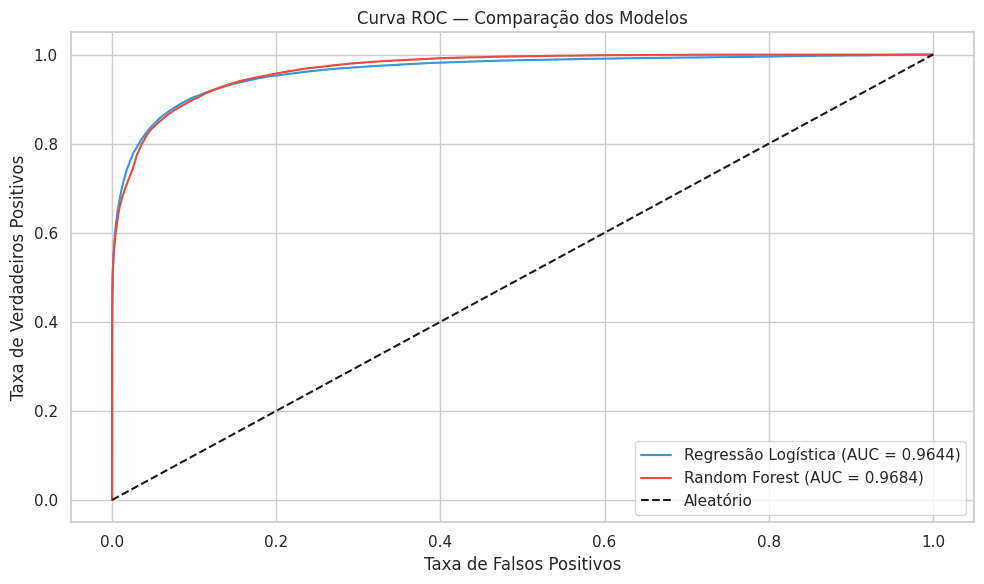

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Tabela comparativa
resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Accuracy': [0.93, 0.92],
    'Precision (atrasado)': [0.89, 0.91],
    'Recall (atrasado)': [0.79, 0.73],
    'F1 (atrasado)': [0.84, 0.81],
    'ROC-AUC': [0.9644, 0.9684]
})

print(resultados.to_string(index=False))

# Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = 0.9644)', color='#3498db')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.9684)', color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC — Comparação dos Modelos')
plt.legend()
plt.tight_layout()
plt.show()

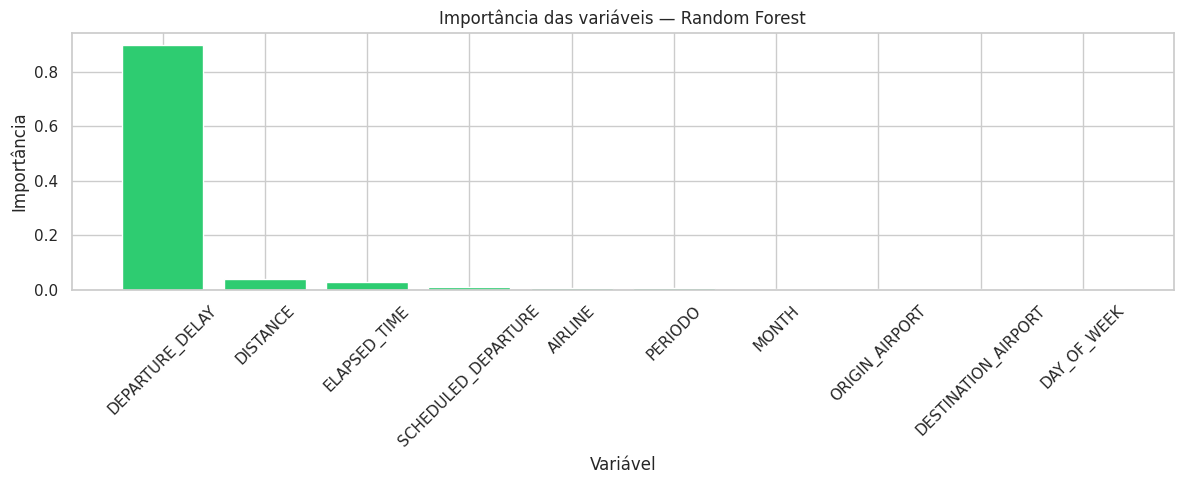

DEPARTURE_DELAY        0.8984
DISTANCE               0.0402
ELAPSED_TIME           0.0294
SCHEDULED_DEPARTURE    0.0087
AIRLINE                0.0071
PERIODO                0.0049
MONTH                  0.0039
ORIGIN_AIRPORT         0.0031
DESTINATION_AIRPORT    0.0025
DAY_OF_WEEK            0.0018
dtype: float64


In [23]:
importancias = pd.Series(rf.feature_importances_, index=features)\
    .sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(importancias.index, importancias.values, color='#2ecc71', edgecolor='white')
plt.title('Importância das variáveis — Random Forest')
plt.xlabel('Variável')
plt.ylabel('Importância')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(importancias.round(4))

In [24]:
print("""
RESUMO DA MODELAGEM SUPERVISIONADA
===================================
Modelo 1 — Regressão Logística
  Accuracy : 93%
  ROC-AUC  : 0.9644
  Recall   : 79% (atrasados)

Modelo 2 — Random Forest  
  Accuracy : 92%
  ROC-AUC  : 0.9684
  Recall   : 73% (atrasados)

Conclusão:
  Ambos os modelos performaram muito bem (AUC > 0.96).
  A Regressão Logística teve melhor Recall — detecta mais
  voos atrasados corretamente.
  O principal preditor de atraso é o DEPARTURE_DELAY (89.8%),
  confirmando o efeito cascata de atrasos na aviação.
""")


RESUMO DA MODELAGEM SUPERVISIONADA
Modelo 1 — Regressão Logística
  Accuracy : 93%
  ROC-AUC  : 0.9644
  Recall   : 79% (atrasados)

Modelo 2 — Random Forest  
  Accuracy : 92%
  ROC-AUC  : 0.9684
  Recall   : 73% (atrasados)

Conclusão:
  Ambos os modelos performaram muito bem (AUC > 0.96).
  A Regressão Logística teve melhor Recall — detecta mais
  voos atrasados corretamente.
  O principal preditor de atraso é o DEPARTURE_DELAY (89.8%),
  confirmando o efeito cascata de atrasos na aviação.



In [25]:
from sklearn.preprocessing import StandardScaler

# Criar perfil por aeroporto
aeroporto_perfil = df.groupby('ORIGIN_AIRPORT').agg(
    total_voos=('ATRASADO', 'count'),
    taxa_atraso=('ATRASADO', 'mean'),
    atraso_medio=('ARRIVAL_DELAY', 'mean'),
    atraso_partida=('DEPARTURE_DELAY', 'mean'),
    distancia_media=('DISTANCE', 'mean'),
    atraso_clima=('WEATHER_DELAY', 'mean'),
    atraso_companhia=('AIRLINE_DELAY', 'mean'),
    atraso_sistema=('AIR_SYSTEM_DELAY', 'mean')
).reset_index()

# Filtrar aeroportos com pelo menos 500 voos
aeroporto_perfil = aeroporto_perfil[aeroporto_perfil['total_voos'] >= 500]

print(f"Aeroportos para clusterizar: {len(aeroporto_perfil)}")
print(aeroporto_perfil.describe().round(2))

Aeroportos para clusterizar: 150
       total_voos  taxa_atraso  atraso_medio  atraso_partida  distancia_media  \
count      150.00       150.00        150.00          150.00           150.00   
mean      6135.75         0.22          8.09           10.80           649.21   
std       9670.98         0.05          4.67            3.98           257.08   
min        518.00         0.10         -2.76            1.50           233.76   
25%        963.25         0.19          4.80            8.33           452.72   
50%       1875.50         0.22          7.50           10.51           626.22   
75%       6885.25         0.25         10.98           13.42           772.41   
max      61854.00         0.36         21.41           20.76          1433.38   

       atraso_clima  atraso_companhia  atraso_sistema  
count        150.00            150.00          150.00  
mean           0.78              3.86            3.36  
std            0.75              1.65            1.52  
min          

In [26]:
# Selecionar features para clustering
features_cluster = [
    'taxa_atraso', 'atraso_medio', 'atraso_partida',
    'distancia_media', 'atraso_clima', 'atraso_companhia', 'atraso_sistema'
]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(aeroporto_perfil[features_cluster])

print(f"Shape para clusterização: {X_cluster.shape}")
print("Dados normalizados com sucesso!")

Shape para clusterização: (150, 7)
Dados normalizados com sucesso!


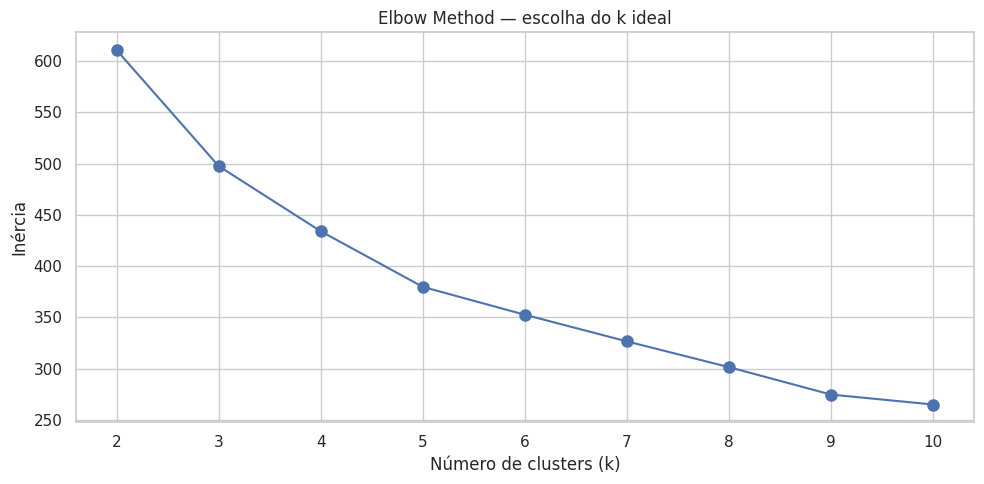

In [27]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, 'bo-', markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Elbow Method — escolha do k ideal')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [28]:
# k=4 geralmente captura bem os perfis: ótimo, bom, ruim, crítico
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
aeroporto_perfil['CLUSTER'] = km_final.fit_predict(X_cluster)

# Perfil médio de cada cluster
perfil_clusters = aeroporto_perfil.groupby('CLUSTER')[features_cluster].mean().round(2)
print(perfil_clusters)

         taxa_atraso  atraso_medio  atraso_partida  distancia_media  \
CLUSTER                                                               
0               0.21          6.69            9.84           622.97   
1               0.26         11.29           13.61           632.48   
2               0.16          2.74            5.84           711.66   
3               0.33         17.38           18.32           683.58   

         atraso_clima  atraso_companhia  atraso_sistema  
CLUSTER                                                  
0                0.53              3.28            3.07  
1                1.00              5.07            4.39  
2                0.38              2.33            1.59  
3                2.21              6.40            5.72  


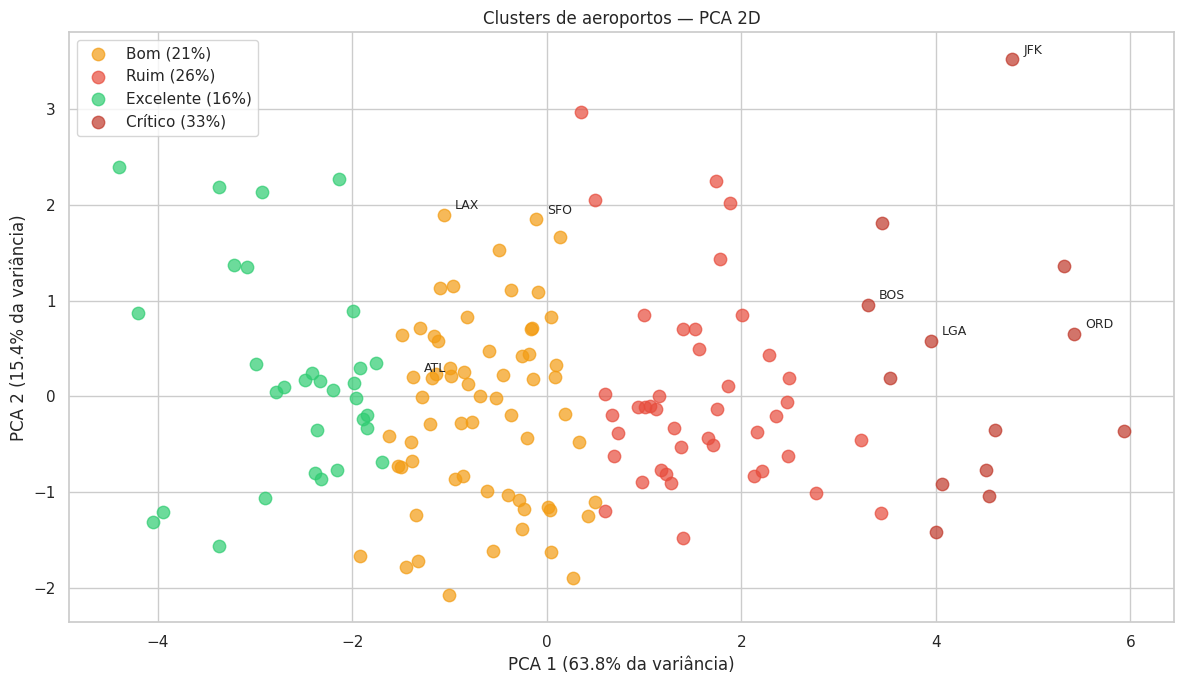


Variância explicada: 79.2%


In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

aeroporto_perfil['PCA1'] = X_pca[:, 0]
aeroporto_perfil['PCA2'] = X_pca[:, 1]

cores = {0: '#f39c12', 1: '#e74c3c', 2: '#2ecc71', 3: '#c0392b'}
labels = {0: 'Bom (21%)', 1: 'Ruim (26%)', 2: 'Excelente (16%)', 3: 'Crítico (33%)'}

plt.figure(figsize=(12, 7))
for cluster in sorted(aeroporto_perfil['CLUSTER'].unique()):
    mask = aeroporto_perfil['CLUSTER'] == cluster
    plt.scatter(
        aeroporto_perfil[mask]['PCA1'],
        aeroporto_perfil[mask]['PCA2'],
        label=labels[cluster],
        color=cores[cluster],
        alpha=0.7,
        s=80
    )

# Destacar alguns aeroportos conhecidos
destaques = ['ORD', 'LAX', 'JFK', 'ATL', 'SFO', 'LGA', 'BOS']
for _, row in aeroporto_perfil[aeroporto_perfil['ORIGIN_AIRPORT'].isin(destaques)].iterrows():
    plt.annotate(
        row['ORIGIN_AIRPORT'],
        (row['PCA1'], row['PCA2']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=9
    )

variancia = pca.explained_variance_ratio_
plt.xlabel(f'PCA 1 ({variancia[0]*100:.1f}% da variância)')
plt.ylabel(f'PCA 2 ({variancia[1]*100:.1f}% da variância)')
plt.title('Clusters de aeroportos — PCA 2D')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nVariância explicada: {sum(variancia)*100:.1f}%")

In [30]:
contagem = aeroporto_perfil.groupby('CLUSTER').agg(
    qtd_aeroportos=('ORIGIN_AIRPORT', 'count'),
    exemplos=('ORIGIN_AIRPORT', lambda x: ', '.join(x.head(5)))
).reset_index()

contagem['perfil'] = contagem['CLUSTER'].map(labels)
print(contagem[['perfil', 'qtd_aeroportos', 'exemplos']].to_string(index=False))

         perfil  qtd_aeroportos                exemplos
      Bom (21%)              64 ABQ, ACY, AEX, ALB, AMA
     Ruim (26%)              42 BIS, BTR, BUF, BWI, CAE
Excelente (16%)              31 ANC, BUR, CAK, ELP, FNT
  Crítico (33%)              13 ASE, BOS, CID, FWA, HPN


In [31]:
print("""
RESUMO DA CLUSTERIZAÇÃO
========================
Método          : K-Means (k=4)
Aeroportos      : 150
Variância PCA   : 79.2% (2 componentes)

Cluster Excelente (16% atraso): 31 aeroportos
  - Menor impacto de clima e sistema aéreo
  - Aeroportos menores e menos congestionados

Cluster Bom (21% atraso): 64 aeroportos  
  - Perfil médio, maioria dos aeroportos

Cluster Ruim (26% atraso): 42 aeroportos
  - Atrasos de companhia e sistema acima da média

Cluster Crítico (33% atraso): 13 aeroportos
  - BOS, CID, HPN, ASE entre os piores
  - Maior impacto de clima (2.21 min médios)
  - Regiões com condições meteorológicas adversas
""")


RESUMO DA CLUSTERIZAÇÃO
Método          : K-Means (k=4)
Aeroportos      : 150
Variância PCA   : 79.2% (2 componentes)

Cluster Excelente (16% atraso): 31 aeroportos
  - Menor impacto de clima e sistema aéreo
  - Aeroportos menores e menos congestionados

Cluster Bom (21% atraso): 64 aeroportos  
  - Perfil médio, maioria dos aeroportos

Cluster Ruim (26% atraso): 42 aeroportos
  - Atrasos de companhia e sistema acima da média

Cluster Crítico (33% atraso): 13 aeroportos
  - BOS, CID, HPN, ASE entre os piores
  - Maior impacto de clima (2.21 min médios)
  - Regiões com condições meteorológicas adversas



In [32]:
print("""
CONCLUSÕES
==========
1. Taxa de atraso geral de 23.1% — 1 em cada 4 voos atrasa.

2. Principais fatores de risco:
   - Voar às segundas ou domingos (27% de atraso)
   - Voos noturnos (29% de atraso)
   - Mês de março (32% de atraso)
   - Companhias F9/Frontier (37.6%) e MQ/Envoy (37.5%)
   - Aeroportos ORD, LGA, JFK, BOS

3. Modelagem supervisionada:
   - Ambos os modelos performaram muito bem (AUC > 0.96)
   - O principal preditor é o DEPARTURE_DELAY (89.8%)
   - Efeito cascata confirmado: atraso na saída = atraso na chegada
   - Regressão Logística teve melhor Recall (79% vs 73%)

4. Clusterização:
   - 4 perfis distintos de aeroportos identificados
   - Aeroportos críticos concentrados em regiões frias
   - 13 aeroportos no cluster crítico (>33% de atraso)

LIMITAÇÕES
==========
1. Base cobre apenas Jan-Mar/2015 — não captura sazonalidade completa.
2. DEPARTURE_DELAY domina o modelo — na prática, só sabemos isso
   quando o voo já está atrasando. Um modelo mais útil usaria
   apenas variáveis conhecidas ANTES do voo.
3. Amostra de 1M de linhas — representa ~17% da base completa.
4. Dados de 2015 — padrões podem ter mudado com o tempo.

PRÓXIMOS PASSOS
===============
1. Treinar modelo sem DEPARTURE_DELAY para predição antecipada.
2. Incorporar dados de clima externos (temperatura, vento, neve).
3. Usar a base completa (5.8M linhas) com mais recursos de hardware.
4. Testar XGBoost e redes neurais para melhorar o Recall.
5. Expandir para todos os meses do ano.
""")


CONCLUSÕES
1. Taxa de atraso geral de 23.1% — 1 em cada 4 voos atrasa.

2. Principais fatores de risco:
   - Voar às segundas ou domingos (27% de atraso)
   - Voos noturnos (29% de atraso)
   - Mês de março (32% de atraso)
   - Companhias F9/Frontier (37.6%) e MQ/Envoy (37.5%)
   - Aeroportos ORD, LGA, JFK, BOS

3. Modelagem supervisionada:
   - Ambos os modelos performaram muito bem (AUC > 0.96)
   - O principal preditor é o DEPARTURE_DELAY (89.8%)
   - Efeito cascata confirmado: atraso na saída = atraso na chegada
   - Regressão Logística teve melhor Recall (79% vs 73%)

4. Clusterização:
   - 4 perfis distintos de aeroportos identificados
   - Aeroportos críticos concentrados em regiões frias
   - 13 aeroportos no cluster crítico (>33% de atraso)

LIMITAÇÕES
1. Base cobre apenas Jan-Mar/2015 — não captura sazonalidade completa.
2. DEPARTURE_DELAY domina o modelo — na prática, só sabemos isso
   quando o voo já está atrasando. Um modelo mais útil usaria
   apenas variáveis conhecida

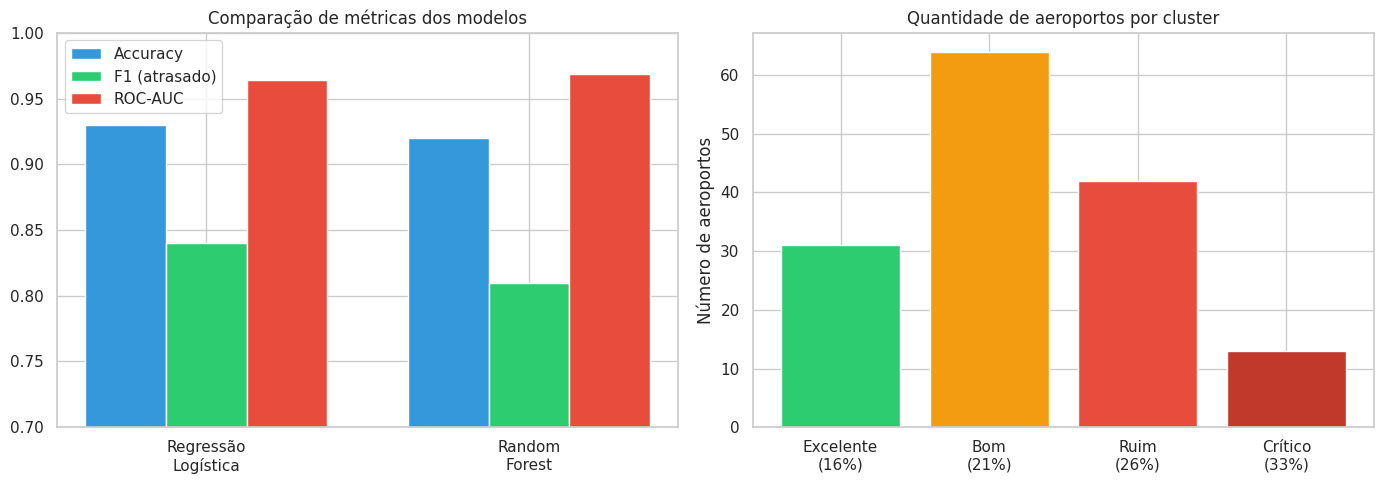

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: comparação de métricas
modelos = ['Regressão\nLogística', 'Random\nForest']
metricas = {
    'Accuracy': [0.93, 0.92],
    'F1 (atrasado)': [0.84, 0.81],
    'ROC-AUC': [0.9644, 0.9684]
}

x = np.arange(len(modelos))
width = 0.25
cores_metricas = ['#3498db', '#2ecc71', '#e74c3c']

for i, (metrica, valores) in enumerate(metricas.items()):
    axes[0].bar(x + i*width, valores, width, label=metrica, color=cores_metricas[i])

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(modelos)
axes[0].set_ylim(0.7, 1.0)
axes[0].set_title('Comparação de métricas dos modelos')
axes[0].legend()

# Gráfico 2: distribuição dos clusters
cluster_labels = ['Excelente\n(16%)', 'Bom\n(21%)', 'Ruim\n(26%)', 'Crítico\n(33%)']
cluster_counts = [31, 64, 42, 13]
cluster_cores = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']

axes[1].bar(cluster_labels, cluster_counts, color=cluster_cores, edgecolor='white')
axes[1].set_title('Quantidade de aeroportos por cluster')
axes[1].set_ylabel('Número de aeroportos')

plt.tight_layout()
plt.show()

In [34]:
# Carregar dados de localização dos aeroportos
airports = pd.read_csv('airports.csv')
print(airports.head())
print(f"\nColunas: {airports.columns.tolist()}")
print(f"Shape: {airports.shape}")

  IATA_CODE                              AIRPORT         CITY STATE COUNTRY  \
0       ABE  Lehigh Valley International Airport    Allentown    PA     USA   
1       ABI             Abilene Regional Airport      Abilene    TX     USA   
2       ABQ    Albuquerque International Sunport  Albuquerque    NM     USA   
3       ABR            Aberdeen Regional Airport     Aberdeen    SD     USA   
4       ABY   Southwest Georgia Regional Airport       Albany    GA     USA   

   LATITUDE  LONGITUDE  
0  40.65236  -75.44040  
1  32.41132  -99.68190  
2  35.04022 -106.60919  
3  45.44906  -98.42183  
4  31.53552  -84.19447  

Colunas: ['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']
Shape: (322, 7)


In [36]:
import folium

# Unir perfil dos aeroportos com localização
mapa_data = aeroporto_perfil.merge(
    airports[['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']],
    left_on='ORIGIN_AIRPORT',
    right_on='IATA_CODE',
    how='inner'
)

print(f"Aeroportos com localização: {len(mapa_data)}")

# Cores por cluster
cores_cluster = {
    0: '#f39c12',  # Bom
    1: '#e74c3c',  # Ruim
    2: '#2ecc71',  # Excelente
    3: '#c0392b'   # Crítico
}

labels_cluster = {
    0: 'Bom (21%)',
    1: 'Ruim (26%)',
    2: 'Excelente (16%)',
    3: 'Crítico (33%)'
}

# Criar mapa centrado nos EUA
mapa = folium.Map(
    location=[39.5, -98.35], 
    zoom_start=4,
    tiles='CartoDB positron'
)

# Adicionar cada aeroporto
for _, row in mapa_data.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=8,
        color=cores_cluster[row['CLUSTER']],
        fill=True,
        fill_color=cores_cluster[row['CLUSTER']],
        fill_opacity=0.8,
        popup=folium.Popup(
            f"""<b>{row['IATA_CODE']} — {row['AIRPORT']}</b><br>
            Cidade: {row['CITY']}, {row['STATE']}<br>
            Cluster: {labels_cluster[row['CLUSTER']]}<br>
            Taxa de atraso: {row['taxa_atraso']*100:.1f}%<br>
            Atraso médio: {row['atraso_medio']:.1f} min""",
            max_width=250
        )
    ).add_to(mapa)

# Adicionar legenda
legenda = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 15px; border-radius: 8px;
     border: 1px solid #ccc; font-size: 13px;">
  <b>Clusters de aeroportos</b><br><br>
  <span style="color:#2ecc71">●</span> Excelente (16% atraso)<br>
  <span style="color:#f39c12">●</span> Bom (21% atraso)<br>
  <span style="color:#e74c3c">●</span> Ruim (26% atraso)<br>
  <span style="color:#c0392b">●</span> Crítico (33% atraso)<br>
</div>
"""
mapa.get_root().html.add_child(folium.Element(legenda))

# Salvar mapa
mapa.save('mapa_clusters_aeroportos.html')
print("Mapa salvo como 'mapa_clusters_aeroportos.html'!")
print(f"Aeroportos plotados: {len(mapa_data)}")

Aeroportos com localização: 150
Mapa salvo como 'mapa_clusters_aeroportos.html'!
Aeroportos plotados: 150


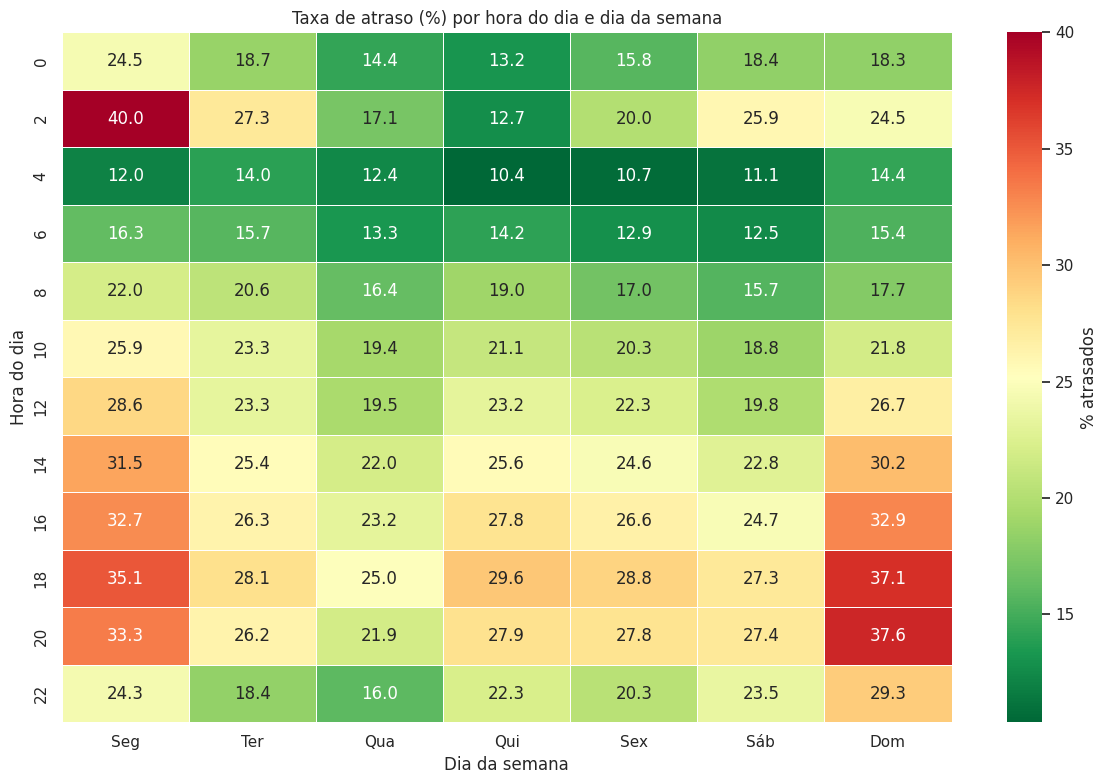

In [37]:
# Extrair hora do SCHEDULED_DEPARTURE
df['HORA'] = df['SCHEDULED_DEPARTURE'].apply(
    lambda x: int(str(int(x)).zfill(4)[:2])
)

# Criar faixas de hora (de 2 em 2 horas)
df['FAIXA_HORA'] = (df['HORA'] // 2) * 2

# Pivot: taxa de atraso por hora e dia da semana
pivot_hora = df.pivot_table(
    values='ATRASADO',
    index='FAIXA_HORA',
    columns='DAY_OF_WEEK',
    aggfunc='mean'
) * 100

pivot_hora.columns = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_hora,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': '% atrasados'}
)
plt.title('Taxa de atraso (%) por hora do dia e dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Hora do dia')
plt.tight_layout()
plt.show()

In [38]:
from sklearn.ensemble import IsolationForest

# Features para detecção de anomalias
features_anomalia = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'ELAPSED_TIME',
    'DISTANCE', 'AIR_SYSTEM_DELAY', 'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

# Usar amostra de 100k para ser mais rápido
df_anomalia = df[features_anomalia].sample(n=100_000, random_state=42)

# Treinar Isolation Forest
iso = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
df_anomalia = df_anomalia.copy()
df_anomalia['ANOMALIA'] = iso.fit_predict(df_anomalia)

# -1 = anomalia, 1 = normal
anomalias = df_anomalia[df_anomalia['ANOMALIA'] == -1]
normais = df_anomalia[df_anomalia['ANOMALIA'] == 1]

print(f"Total analisado : {len(df_anomalia):,}")
print(f"Voos normais    : {len(normais):,} ({len(normais)/len(df_anomalia)*100:.1f}%)")
print(f"Anomalias       : {len(anomalias):,} ({len(anomalias)/len(df_anomalia)*100:.1f}%)")
print(f"\nPerfil médio das anomalias:")
print(anomalias[features_anomalia].mean().round(1))

Total analisado : 100,000
Voos normais    : 99,000 (99.0%)
Anomalias       : 1,000 (1.0%)

Perfil médio das anomalias:
DEPARTURE_DELAY         242.8
ARRIVAL_DELAY           257.4
ELAPSED_TIME            190.6
DISTANCE               1068.0
AIR_SYSTEM_DELAY         45.3
AIRLINE_DELAY           109.0
LATE_AIRCRAFT_DELAY      70.0
WEATHER_DELAY            33.1
dtype: float64


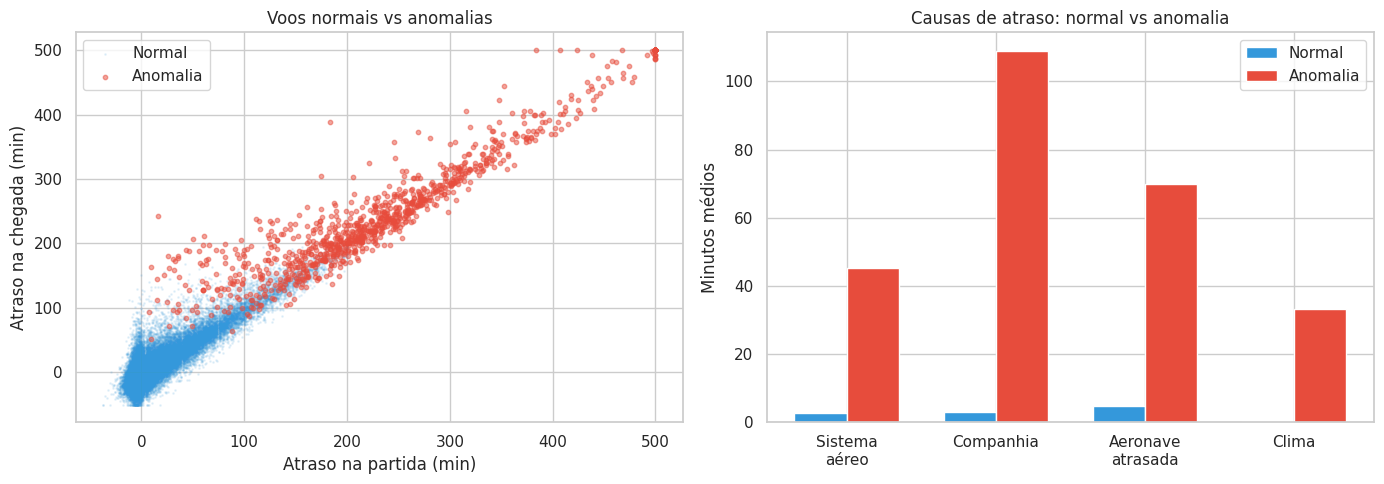

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: dispersão normais vs anomalias
axes[0].scatter(
    normais['DEPARTURE_DELAY'].clip(-50, 200),
    normais['ARRIVAL_DELAY'].clip(-50, 200),
    alpha=0.1, color='#3498db', s=1, label='Normal'
)
axes[0].scatter(
    anomalias['DEPARTURE_DELAY'].clip(-50, 500),
    anomalias['ARRIVAL_DELAY'].clip(-50, 500),
    alpha=0.5, color='#e74c3c', s=10, label='Anomalia'
)
axes[0].set_xlabel('Atraso na partida (min)')
axes[0].set_ylabel('Atraso na chegada (min)')
axes[0].set_title('Voos normais vs anomalias')
axes[0].legend()

# Gráfico 2: comparação das causas
causas_labels = ['Sistema\naéreo', 'Companhia', 'Aeronave\natrasada', 'Clima']
causas_normal = normais[['AIR_SYSTEM_DELAY', 'AIRLINE_DELAY', 
                          'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].mean()
causas_anomalia = anomalias[['AIR_SYSTEM_DELAY', 'AIRLINE_DELAY',
                              'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']].mean()

x = np.arange(len(causas_labels))
width = 0.35

axes[1].bar(x - width/2, causas_normal, width, label='Normal', color='#3498db')
axes[1].bar(x + width/2, causas_anomalia, width, label='Anomalia', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(causas_labels)
axes[1].set_title('Causas de atraso: normal vs anomalia')
axes[1].set_ylabel('Minutos médios')
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Usar amostra menor para não travar a memória
df_semi = df.sample(n=20_000, random_state=42).reset_index(drop=True)

# Features
features_semi = [
    'MONTH', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE',
    'DEPARTURE_DELAY', 'DISTANCE', 'ELAPSED_TIME'
]

X_semi = df_semi[features_semi].values
y_semi = df_semi['ATRASADO'].values

# Simular cenário semi-supervisionado:
# apenas 10% dos dados têm label conhecido
np.random.seed(42)
n_rotulados = int(0.10 * len(X_semi))
indices_rotulados = np.random.choice(len(X_semi), n_rotulados, replace=False)

# -1 = sem label (convenção do scikit-learn)
y_semi_parcial = np.full(len(X_semi), -1)
y_semi_parcial[indices_rotulados] = y_semi[indices_rotulados]

print(f"Total de amostras      : {len(X_semi):,}")
print(f"Com label (10%)        : {(y_semi_parcial != -1).sum():,}")
print(f"Sem label (90%)        : {(y_semi_parcial == -1).sum():,}")

# Normalizar
scaler_semi = StandardScaler()
X_semi_scaled = scaler_semi.fit_transform(X_semi)

# Treinar Label Propagation
print("\nTreinando Label Propagation...")
lp = LabelPropagation(kernel='knn', n_neighbors=7, max_iter=1000)
lp.fit(X_semi_scaled, y_semi_parcial)

# Avaliar nos dados não rotulados
indices_nao_rotulados = np.where(y_semi_parcial == -1)[0]
y_pred_semi = lp.predict(X_semi_scaled[indices_nao_rotulados])
y_true_semi = y_semi[indices_nao_rotulados]

print("\n--- Label Propagation (avaliado nos 90% sem label) ---")
print(classification_report(y_true_semi, y_pred_semi,
      target_names=['Não atrasado', 'Atrasado']))

Total de amostras      : 20,000
Com label (10%)        : 2,000
Sem label (90%)        : 18,000

Treinando Label Propagation...

--- Label Propagation (avaliado nos 90% sem label) ---
              precision    recall  f1-score   support

Não atrasado       0.86      0.99      0.92     13893
    Atrasado       0.93      0.45      0.61      4107

    accuracy                           0.87     18000
   macro avg       0.90      0.72      0.76     18000
weighted avg       0.88      0.87      0.85     18000

